In [24]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score
from metagen.framework import Domain
from src.Utils import plot_performance_analysis
from src.NN_Utils import build_meta_neural_network
from metagen.metaheuristics.rs import RandomSearch
import joblib

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<h2>Lectura y Tratamiento de Datos</h2>

In [2]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]

**Validación por Retención (Tratamiento como Serie Temporal)**

In [3]:
# VALIDACIÓN POR RETENCIÓN PARA EVALUACIÓN FINAL DEL MEJOR MODELO
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

<h2>Búsqueda Aleatoria de Hiperparámetros</h2>

In [4]:
NN_domain = Domain()
NN_domain.define_categorical("activation", ["relu", "elu"])
NN_domain.define_real("dropout", 0.0, 0.3)
NN_domain.define_categorical("use_batch_norm", [True, False])
NN_domain.define_categorical("learning_rate", [1e-4, 5e-4, 1e-3, 5e-3, 1e-2])
NN_domain.define_categorical("optimizer", ["sgd", "adam"])
NN_domain.define_integer("n_hidden_q", 2, 5)
NN_domain.define_integer("n_neurons_q", 64, 256)
NN_domain.define_integer("n_hidden_v", 1, 2)
NN_domain.define_integer("n_neurons_v", 64, 256)
NN_domain.define_integer("n_hidden_p", 2, 5)
NN_domain.define_integer("n_neurons_p", 64, 256)

In [6]:
def build_nn_fitness(num_volts, idx_perd, idx_qgen, idx_volts, x, y):
    def nn_fitness(solution):
        tscv = TimeSeriesSplit(n_splits=3)

        val_losses = []

        for train_index, test_index in tscv.split(x):
            model = build_meta_neural_network(solution, input_dim=x.shape[1], num_voltages=num_volts)

            x_tr, x_val = x.iloc[train_index], x.iloc[test_index]
            y_tr, y_val = y.iloc[train_index], y.iloc[test_index]

            scaler_x_fold = MinMaxScaler()
            scaler_y_fold = MinMaxScaler()

            xs_tr = scaler_x_fold.fit_transform(x_tr)
            ys_tr = scaler_y_fold.fit_transform(y_tr)

            xs_val = scaler_x_fold.transform(x_val)
            ys_val = scaler_y_fold.transform(y_val)

            dict_y_tr = {
                'out_volt': ys_tr[:, idx_volts],
                'out_perd': ys_tr[:, idx_perd:idx_perd+1],
                'out_qgen7': ys_tr[:, idx_qgen:idx_qgen+1]
            }
            dict_y_val = {
                'out_volt': ys_val[:, idx_volts],
                'out_perd': ys_val[:, idx_perd:idx_perd+1],
                'out_qgen7': ys_val[:, idx_qgen:idx_qgen+1]
            }

            stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

            model.fit(xs_tr, dict_y_tr, validation_data=(xs_val, dict_y_val),
                      epochs=25, batch_size=32, verbose=0, callbacks=[stop_early])

            metrics = model.evaluate(xs_val, dict_y_val, verbose=0, return_dict=True)
            val_losses.append(metrics['loss'])

        return np.mean(val_losses)
    return nn_fitness

In [7]:
volts = len([c for c in Y.columns if c.startswith('V')])
idx_v = [Y.columns.get_loc(c) for c in Y.columns if c.startswith('V')]
idx_p = Y.columns.get_loc('PERD')
idx_q = Y.columns.get_loc('QGEN7')

In [8]:
fitness = build_nn_fitness(volts, idx_p, idx_q, idx_v, x_train, y_train)
NN_solution = RandomSearch(NN_domain, fitness, population_size=3, max_iterations=20).run()
print(NN_solution)

F = 0.013343024998903275	{activation = elu , dropout = 0.2596563372571659 , learning_rate = 0.0005 , n_hidden_p = 5 , n_hidden_q = 5 , n_hidden_v = 1 , n_neurons_p = 233 , n_neurons_q = 149 , n_neurons_v = 114 , optimizer = adam , use_batch_norm = False}


<h2>Evaluación del Mejor Modelo Aleatorio</h2>

In [9]:
best_model = build_meta_neural_network(NN_solution, input_dim=x_train.shape[1], num_voltages=volts)

In [10]:
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

xs_train = scaler_x.fit_transform(x_train)
ys_train = scaler_y.fit_transform(y_train)
xs_test = scaler_x.transform(x_test)

dict_y_train = {
    'out_volt': ys_train[:, idx_v],
    'out_perd': ys_train[:, idx_p:idx_p+1],
    'out_qgen7': ys_train[:, idx_q:idx_q+1]
}

In [11]:
stop_early_final = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
best_model.fit(xs_train, dict_y_train, epochs=55, batch_size=32, verbose=1, callbacks=[stop_early_final])

Epoch 1/55
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0784 - out_perd_loss: 0.0062 - out_perd_mae: 0.0528 - out_perd_mape: 1155.9155 - out_perd_r2_score: 0.1846 - out_qgen7_loss: 0.0277 - out_qgen7_mae: 0.1210 - out_qgen7_mape: 10646.0283 - out_qgen7_r2_score: 0.2828 - out_volt_loss: 0.0107 - out_volt_mae: 0.0699 - out_volt_mape: 2157.8115 - out_volt_r2_score: 0.3135 
Epoch 2/55
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0346 - out_perd_loss: 9.0012e-04 - out_perd_mae: 0.0228 - out_perd_mape: 1016.8679 - out_perd_r2_score: 0.8814 - out_qgen7_loss: 0.0157 - out_qgen7_mae: 0.0868 - out_qgen7_mape: 10004.2324 - out_qgen7_r2_score: 0.5942 - out_volt_loss: 0.0015 - out_volt_mae: 0.0301 - out_volt_mape: 1093.7164 - out_volt_r2_score: 0.9049
Epoch 3/55
2624/2624 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0274 - out_perd_loss: 4.3687e-04 - out_perd_mae: 0.0156 - out_perd_mape: 280.7392 - out_perd_r2_score: 0.9424 - out_qgen7_loss: 0.0128 - out_qgen7_mae: 0.0753 - out_qgen7_

In [12]:
preds_list = best_model.predict(xs_test)
preds_concat = np.hstack([preds_list[0], preds_list[1], preds_list[2]])
predictions = scaler_y.inverse_transform(preds_concat)

656/656 ━━━━━━━━━━━━━━━━━━━━ 1s 854us/step


In [17]:
random_MAE = mean_absolute_error(y_test, predictions, multioutput='raw_values')
random_MAPE = mean_absolute_percentage_error(y_test, predictions, multioutput='raw_values')

# DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE_shifted = mean_absolute_percentage_error(y_test + 1.0, predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, predictions, multioutput='raw_values')

In [18]:
# RESULTADOS CON MAPE DESPLAZADO
random_data_score_shifted = np.vstack([random_MAE, random_MAPE_shifted, random_R2])
evaluations_shifted = pd.DataFrame(random_data_score_shifted, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations_shifted

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001742,0.001748,0.001752,0.001752,0.001752,0.001753,0.001753,0.001753,0.001753,0.001753,0.001753,0.001271,0.001270,0.570979,0.009926
MAPE,0.000883,0.000887,0.000888,0.000889,0.000889,0.000889,0.000889,0.000889,0.000889,0.000889,0.000889,0.000641,0.000641,0.089325,0.009297
R2,0.973104,0.973276,0.973380,0.973393,0.973408,0.973426,0.973338,0.973389,0.973390,0.973392,0.973395,0.981206,0.981209,0.949580,0.861454


In [19]:
# RESULTADOS SIN DESPLAZAMIENTO
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
evaluations = pd.DataFrame(random_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001742,0.001748,0.001752,0.001752,0.001752,0.001753,0.001753,0.001753,0.001753,0.001753,0.001753,0.001271,0.001270,0.570979,9.925749e-03
MAPE,0.001791,0.001799,0.001803,0.001804,0.001804,0.001806,0.001805,0.001804,0.001804,0.001805,0.001805,0.001295,0.001295,0.110965,1.445427e+13
R2,0.973104,0.973276,0.973380,0.973393,0.973408,0.973426,0.973338,0.973389,0.973390,0.973392,0.973395,0.981206,0.981209,0.949580,8.614540e-01


In [20]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE DESPLAZADO)
volts_columns = [c for c in y_train.columns if c.startswith('V')]
pd.DataFrame({
    'Voltajes (Desplazados)': evaluations_shifted[volts_columns].mean(axis=1),
    'Pérdidas (Desplazada)': evaluations_shifted['PERD'],
    'Potencia Reactiva (Desplazada)': evaluations_shifted['QGEN7']
})

,Voltajes (Desplazados),Pérdidas (Desplazada),Potencia Reactiva (Desplazada)
MAE,0.001677,0.570979,0.009926
MAPE,0.000850,0.089325,0.009297
R2,0.974562,0.949580,0.861454


In [21]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE SIN DESPLAZAMIENTO)
pd.DataFrame({
    'Voltajes': evaluations[volts_columns].mean(axis=1),
    'Pérdidas': evaluations['PERD'],
    'Potencia Reactiva': evaluations['QGEN7']
})

,Voltajes,Pérdidas,Potencia Reactiva
MAE,0.001677,0.570979,9.925749e-03
MAPE,0.001725,0.110965,1.445427e+13
R2,0.974562,0.949580,8.614540e-01


<h2>Figuras de Rendimiento del Mejor Modelo</h2>

In [23]:
best_model.save('../models/MO_MetaGen_NeuralNetwork.keras')
joblib.dump(scaler_x, '../models/normalizers/MO_MetaGen_NeuralNetwork_Normalizer_x.pkl')
joblib.dump(scaler_y, '../models/normalizers/MO_MetaGen_NeuralNetwork_Normalizer_y.pkl')

['../models/normalizers/MO_Best_NeuralNetwork_Normalizer_y.pkl']

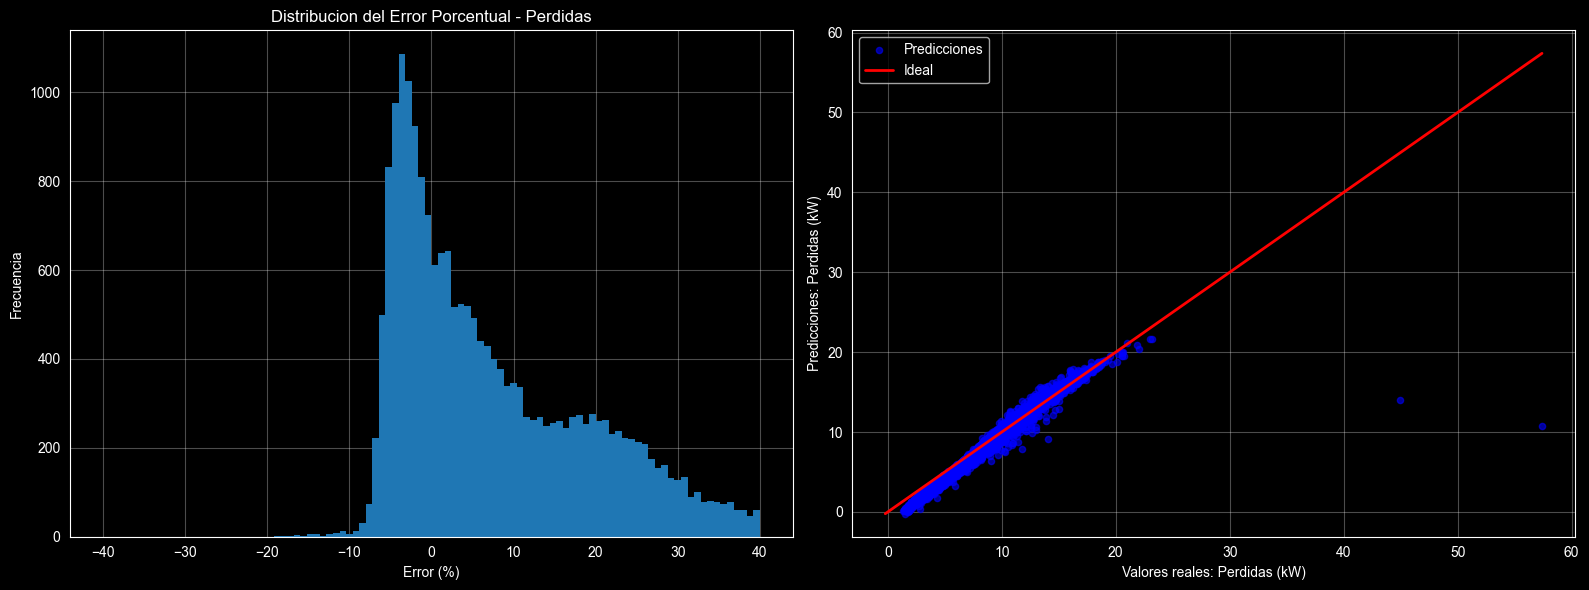

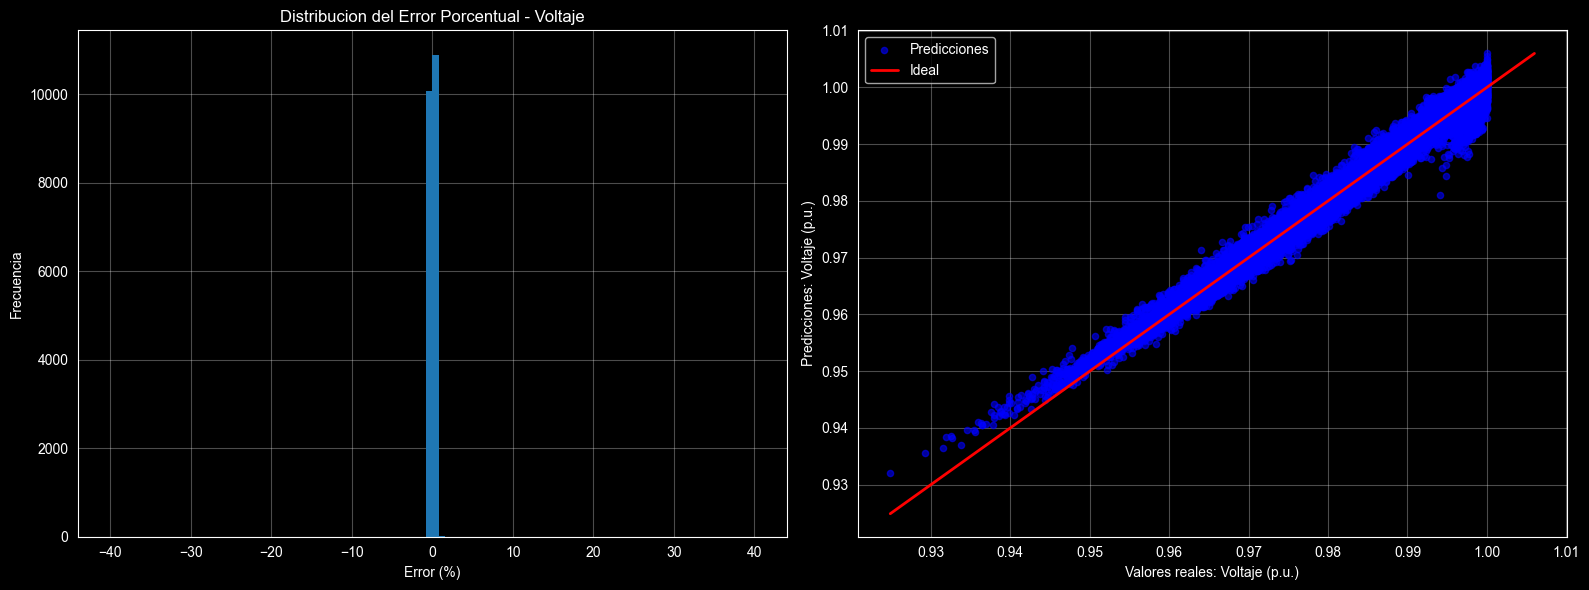

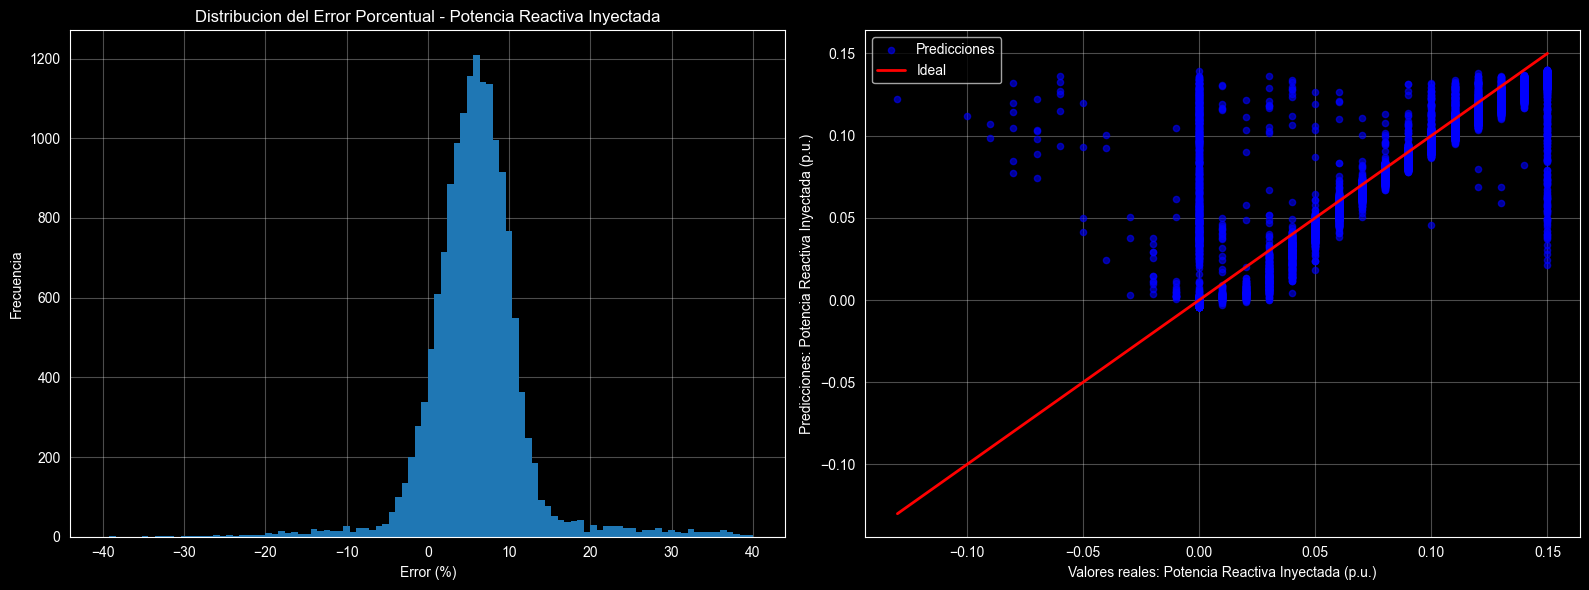

In [28]:
plot_performance_analysis(
    y_test['PERD'],
    predictions[:, -2],
    variable_name="Perdidas",
    unit_label="kW",
    path='../figures/NeuralNetwork/MO_MetaGen_NeuralNetwork_Perd.png'
)
plot_performance_analysis(
    y_test['V13'],
    predictions[:, -4],
    variable_name="Voltaje",
    unit_label="p.u.",
    path='../figures/NeuralNetwork/MO_MetaGen_NeuralNetwork_V13.png'
)
plot_performance_analysis(
    y_test['QGEN7'],
    predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/NeuralNetwork/MO_MetaGen_NeuralNetwork_QGen.png'
)